# Robust iSWAP Gate — Gate Frame with Detuned Drives

Optimize a robust iSWAP using:
- Qubits on-resonance (q2 flux-tuned to q1)
- Gaussian square coupling pulse with computed V_rise / V_fall
- Microwave drives detuned ±2 MHz from gate frequency (crosstalk avoidance)
- Variational adjoint robustness to ZI, IZ, ZZ
- Cubic spline pulse parameterization

## 1. Imports

In [1]:
import Pkg
Pkg.activate(".")
piccolo_path = joinpath(@__DIR__, "..", "..", "..", "Piccolo.jl")
Pkg.develop(path=piccolo_path)
directtrajopt_path = joinpath(@__DIR__, "..", "..", "..", "DirectTrajOpt.jl")
Pkg.develop(path=directtrajopt_path)
Pkg.add(["CairoMakie", "Ipopt", "FFTW"])
Pkg.instantiate()

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/modulate_iswap/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/mo

In [2]:
using Revise
using Piccolo
using LinearAlgebra
using Random
using Printf
using CairoMakie
using FFTW

## 2. Parameters

In [3]:
# --- Pauli operators ---
XX = operator_from_string("XX")
YY = operator_from_string("YY")
XY = operator_from_string("XY")
YX = operator_from_string("YX")
XI = operator_from_string("XI")
YI = operator_from_string("YI")
IX = operator_from_string("IX")
IY = operator_from_string("IY")
IZ = operator_from_string("IZ")
ZI = operator_from_string("ZI")
ZZ = operator_from_string("ZZ")

# --- Physical parameters ---
g_eff = 2π * 0.005       # flat-top coupling: 10 MHz in rad/ns
δ₁₂ = 2π * 0.06          # idle detuning: 60 MHz in rad/ns

# --- Drive detunings from gate frame (ω₁) ---
# Q1 drive: 2 MHz below ω₁
# Q2 drive: 2 MHz above ω₁ (= ω₂_tuned since q2 is on-res)
Δ_mw1 = -2π * 0.00     # -1 MHz in rad/ns
Δ_mw2 = +2π * 0.00     # +1 MHz in rad/ns

# --- Control bounds ---
a_bound = 2π * 0.01     # 10 MHz microwave amplitude bound
drive_bounds = fill(a_bound, 4)  # 4 microwave channels (no g_eff channel)

# --- Gaussian edge parameters ---
σ_rise = 1.0            # ns, Gaussian rise/fall width (bandwidth ~80 MHz, safe)

# --- Gate target ---
U_iswap = exp(-im * π/4 * (XX + YY))

# --- Optimization parameters ---
F_threshold = 0.9999
Q_r = 1e4             # robustness weight
n_samples = 300         # spline interpolation samples
N_knots = 24            # spline knot points
num_iter = 1000

println("g_eff = ", round(g_eff/(2π)*1e3, digits=1), " MHz")
println("δ₁₂ = ", round(δ₁₂/(2π)*1e3, digits=1), " MHz")
println("Δ_mw1 = ", round(Δ_mw1/(2π)*1e3, digits=1), " MHz")
println("Δ_mw2 = ", round(Δ_mw2/(2π)*1e3, digits=1), " MHz")
println("a_bound = ", round(a_bound/(2π)*1e3, digits=1), " MHz")
println("σ_rise = ", σ_rise, " ns (BW ≈ ", round(1/(2π*σ_rise*1e-9)/1e6, digits=0), " MHz)")

g_eff = 5.0 MHz
δ₁₂ = 60.0 MHz
Δ_mw1 = -0.0 MHz
Δ_mw2 = 0.0 MHz
a_bound = 10.0 MHz
σ_rise = 1.0 ns (BW ≈ 159.0 MHz)


## 3. Compute V_rise, V_fall, and U_goal

The Gaussian edges produce pure XX+YY rotations. Since the qubits are
on-resonance during the gate, V depends only on the integrated area.

```
V_rise = exp(-i A_rise (XX+YY))
V_fall = exp(-i A_fall (XX+YY))
U_goal = exp(-i (π/4 - A_rise - A_fall) (XX+YY))
```

In [4]:
# --- Gaussian edge envelope ---
# g(t) = g_eff * exp(-(t - t_center)² / (2σ²))
# Truncate at ±4σ for the buffer region

buffer_duration = 4 * σ_rise  # ns, total buffer = ±4σ
dt_fine = 0.01                # fine grid for integration (ns)

t_rise = collect(0:dt_fine:buffer_duration)
g_rise = g_eff .* exp.(-(t_rise .- buffer_duration).^2 ./ (2 * σ_rise^2))
# At t=0: g ≈ 0 (4σ away). At t=buffer_duration: g = g_eff (fully on).

t_fall = collect(0:dt_fine:buffer_duration)
g_fall = g_eff .* exp.(-(t_fall).^2 ./ (2 * σ_rise^2))
# At t=0: g = g_eff (fully on). At t=buffer_duration: g ≈ 0 (4σ away).

# --- Integrated areas ---
A_rise = sum(g_rise) * dt_fine
A_fall = sum(g_fall) * dt_fine

println("Buffer duration: ", buffer_duration, " ns")
println("A_rise = ", A_rise, " rad")
println("A_fall = ", A_fall, " rad")
println("A_rise + A_fall = ", A_rise + A_fall, " rad")
println("π/4 = ", π/4, " rad")
println()

# --- Target rotation angle for flat-top ---
θ_goal = π/4 - A_rise - A_fall
@assert θ_goal > 0 "Edges over-rotate past iSWAP! Reduce g_eff or σ_rise."

println("θ_goal = ", θ_goal, " rad")
println("θ_goal / (π/4) = ", round(θ_goal / (π/4) * 100, digits=1), "% of full iSWAP")

# --- Build U_goal ---
U_goal = exp(-im * θ_goal * (XX + YY))

# --- Build V_rise, V_fall for verification ---
V_rise = exp(-im * A_rise * (XX + YY))
V_fall = exp(-im * A_fall * (XX + YY))

# --- Verify: V_fall · U_goal · V_rise = iSWAP ---
U_total = V_fall * U_goal * V_rise
F_check = abs(tr(U_iswap' * U_total)) / 4
println()
println("Verification: F(V_fall · U_goal · V_rise, iSWAP) = ", F_check)

# --- Flat-top duration estimate (from coupling alone, no microwaves) ---
T_flat_est = θ_goal / g_eff
println("Estimated flat-top duration (coupling only): ", round(T_flat_est, digits=2), " ns")

Buffer duration: 4.0 ns
A_rise = 0.039528662791517045 rad
A_fall = 0.03952866279151704 rad
A_rise + A_fall = 0.07905732558303408 rad
π/4 = 0.7853981633974483 rad

θ_goal = 0.7063408378144143 rad
θ_goal / (π/4) = 89.9% of full iSWAP

Verification: F(V_fall · U_goal · V_rise, iSWAP) = 1.0
Estimated flat-top duration (coupling only): 22.48 ns


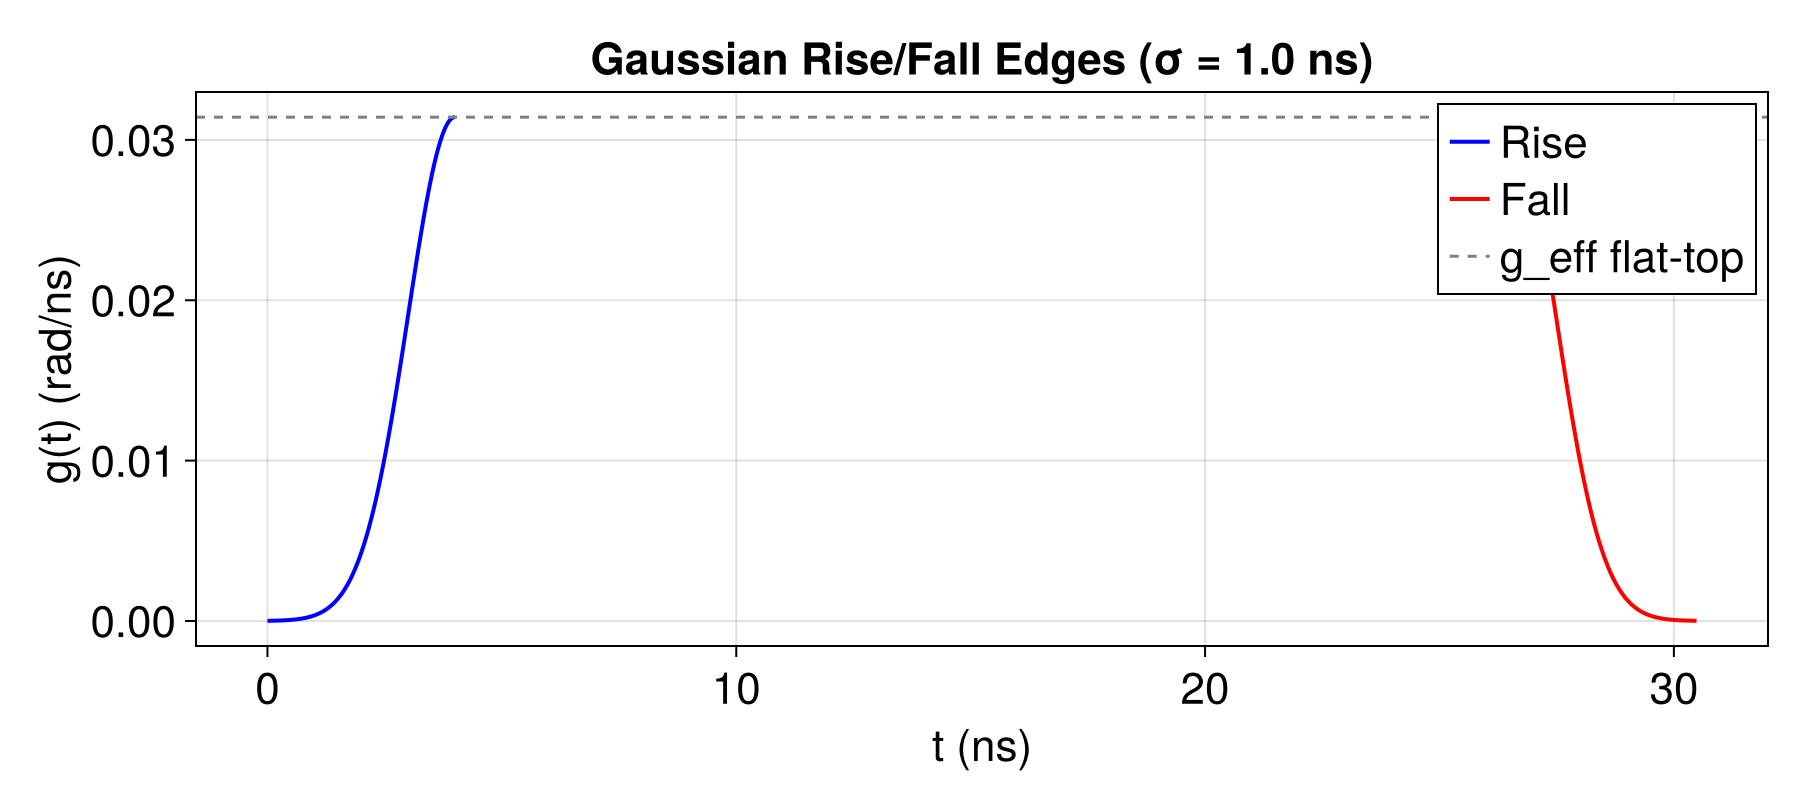

CairoMakie.Screen{IMAGE}


In [5]:
# Plot Gaussian edges
fig = Figure(fontsize=22, size=(900, 400))
ax = Axis(fig[1, 1], xlabel="t (ns)", ylabel="g(t) (rad/ns)",
    title="Gaussian Rise/Fall Edges (σ = $(σ_rise) ns)")
lines!(ax, t_rise, g_rise, label="Rise", linewidth=2, color=:blue)
lines!(ax, t_fall .+ buffer_duration .+ T_flat_est, g_fall, label="Fall", linewidth=2, color=:red)
hlines!(ax, [g_eff], linestyle=:dash, color=:gray, label="g_eff flat-top")
axislegend(ax)
display(fig)

## 4. Gate Frame Hamiltonian

Both qubits on-resonance at ω₁. Drives detuned by Δ_mw1, Δ_mw2.
The coupling is time-independent. The drive operators oscillate at the detuning.

In [6]:
# Gate-frame Hamiltonian for the flat-top region
# H(u, t) = g_eff(XX+YY) + modulated microwave drives
#
# 4 control channels: u = [u_X1, u_Y1, u_X2, u_Y2]
# g_eff is NOT a control — it's in the drift

function H_gate_frame(u, t)
    uX1, uY1, uX2, uY2 = u

    # Drift: constant coupling
    H = g_eff * (XX + YY)

    # Qubit 1 drives (detuned by Δ_mw1)
    c1 = cos(Δ_mw1 * t)
    s1 = sin(Δ_mw1 * t)
    H += uX1 * (XI * c1 + YI * s1)
    H += uY1 * (YI * c1 - XI * s1)

    # Qubit 2 drives (detuned by Δ_mw2)
    c2 = cos(Δ_mw2 * t)
    s2 = sin(Δ_mw2 * t)
    H += uX2 * (IX * c2 + IY * s2)
    H += uY2 * (IY * c2 - IX * s2)

    return H
end

# Variational error generators (time-independent)
H_vars = [
    (u, t) -> ZI,
    (u, t) -> IZ,
    (u, t) -> ZZ,
]

varsys = VariationalQuantumSystem(
    H_gate_frame, H_vars, 4, drive_bounds;
    time_dependent = true
)

println("levels = ", varsys.levels,
        "  n_drives = ", varsys.n_drives,
        "  n_vars = ", length(varsys.G_vars),
        "  time_dep = ", varsys.time_dependent)

levels = 4  n_drives = 4  n_vars = 3  time_dep = true


## 5. T sweep — optimize, verify, compare default vs robust at multiple T_f

Each T_f produces a separate robust optimization. Δt is tightly bounded around T_f / N_knots so
the total flat-top time stays close to T_f. The default Gaussian-square baseline is built once
(its width is set by the π/4 area target, independent of T_f).


In [ ]:
# --- T sweep parameters ---
T_f_list = [30.0, 40.0, 50.0, 70.0, 100.0]   # ns; flat-top durations to compare
εs         = collect(range(-0.02, 0.02, length=101))
errors     = [(ZI, "ZI"), (IZ, "IZ"), (ZZ, "ZZ")]

# Per-T_f results
F_vs_eps_T = Dict{Float64, Dict{String, Vector{Float64}}}()
trajs_T    = Dict{Float64, Any}()

# Default GS curves are T-independent; built once below
F_default_vs_eps = Dict{String, Vector{Float64}}()


In [ ]:
# Output directory for sweep figures
outdir = "robust_iswap_detuned"
mkpath(joinpath(outdir, "figs"))


In [ ]:
# --- Build default Gaussian-square pulse (T-independent) ---
function gaussian_square_area(flat_ns; g_eff=g_eff, σ=σ_rise, dt=0.01, trunc=4)
    buf = trunc * σ
    t_rise = collect(0:dt:buf)
    g_rise_seg = g_eff .* exp.(-(t_rise .- buf).^2 ./ (2σ^2))
    A_rise = sum(g_rise_seg) * dt
    A_flat = g_eff * flat_ns
    A_fall = A_rise
    return A_rise + A_flat + A_fall
end

let target = π/4, lo = 0.0, hi = 400.0
    for _ in 1:100
        mid = (lo + hi) / 2
        gaussian_square_area(mid) < target ? (lo = mid) : (hi = mid)
    end
    global flat_default = (lo + hi) / 2
end

buf        = 4 * σ_rise
dt_default = 0.01
T_default  = buf + flat_default + buf
t_default  = collect(0:dt_default:T_default)
g_default  = zeros(length(t_default))
for (i, t) in enumerate(t_default)
    if t < buf
        g_default[i] = g_eff * exp(-(t - buf)^2 / (2σ_rise^2))
    elseif t < buf + flat_default
        g_default[i] = g_eff
    else
        g_default[i] = g_eff * exp(-(t - buf - flat_default)^2 / (2σ_rise^2))
    end
end
println("Default GS: flat_default = ", round(flat_default, digits=2), " ns,  T_default = ",
        round(T_default, digits=2), " ns")


In [ ]:
# --- Verification helpers ---
function simulate_default_fidelity(g_pulse, t_pulse, dt, ε_op, ε_val)
    N = length(g_pulse)
    T_ns = t_pulse[end]
    function H_default(u, t)
        idx = clamp(round(Int, t / dt) + 1, 1, N)
        return g_pulse[idx] * (XX + YY) + ε_val * ε_op
    end
    def_sys = QuantumSystem(H_default, Float64[]; time_dependent=true)
    ts_prop = collect(LinRange(0.0, T_ns, min(N, 2000)))
    dummy_pulse = LinearSplinePulse(zeros(0, length(ts_prop)), ts_prop)
    qtraj = UnitaryTrajectory(def_sys, dummy_pulse, U_iswap)
    U_def = qtraj(T_ns)
    return abs2(tr(U_iswap' * U_def)) / 4^2
end

function simulate_edge_unitary(g_pulse, t_pulse, dt, ε_op, ε_val)
    N = length(g_pulse)
    T_ns = t_pulse[end]
    function H_edge_err(u, t)
        idx = clamp(round(Int, t / dt) + 1, 1, N)
        return g_pulse[idx] * (XX + YY) + ε_val * ε_op
    end
    edge_sys = QuantumSystem(H_edge_err, Float64[]; time_dependent=true)
    ts_prop = collect(LinRange(0.0, T_ns, min(N, 2000)))
    dummy_pulse = LinearSplinePulse(zeros(0, length(ts_prop)), ts_prop)
    qtraj = UnitaryTrajectory(edge_sys, dummy_pulse, Matrix{ComplexF64}(I, 4, 4))
    return qtraj(T_ns)
end

dt_edge = 0.01
buf_edge = 4 * σ_rise
t_rise_fine = collect(0:dt_edge:buf_edge)
g_rise_fine = g_eff .* exp.(-(t_rise_fine .- buf_edge).^2 ./ (2 * σ_rise^2))
t_fall_fine = collect(0:dt_edge:buf_edge)
g_fall_fine = g_eff .* exp.(-(t_fall_fine).^2 ./ (2 * σ_rise^2))

function simulate_full_gate_fidelity(traj, ε_op, ε_val)
    V_rise_err = simulate_edge_unitary(g_rise_fine, t_rise_fine, dt_edge, ε_op, ε_val)
    V_fall_err = simulate_edge_unitary(g_fall_fine, t_fall_fine, dt_edge, ε_op, ε_val)

    ts  = vec(traj[:t])
    us  = traj[:u]
    dus = traj[:du]

    function H_with_error(u, t)
        return H_gate_frame(u, t) + ε_val * ε_op
    end

    err_sys    = QuantumSystem(H_with_error, drive_bounds; time_dependent=true)
    nlp_pulse  = CubicSplinePulse(us, dus, ts)
    qtraj      = UnitaryTrajectory(err_sys, nlp_pulse, U_goal)
    U_flat_err = qtraj(ts[end])

    U_full_err = V_fall_err * U_flat_err * V_rise_err
    return abs2(tr(U_iswap' * U_full_err)) / 4^2
end

# Run the (T-independent) default sweep once
for (err_op, err_name) in errors
    F_curve = Float64[]
    for ε in εs
        push!(F_curve, simulate_default_fidelity(g_default, t_default, dt_default, err_op, ε))
    end
    F_default_vs_eps[err_name] = F_curve
    println("Default $err_name sweep complete")
end


In [ ]:
# --- T sweep: solve + verify for each T_f ---
for T_f in T_f_list
    println("\n========== T_f = ", T_f, " ns ==========")
    Δt_T = T_f / N_knots

    Random.seed!(42)
    controls_T = 2 .* a_bound .* rand(4, n_samples) .- a_bound
    times_T    = collect(LinRange(0.0, T_f, n_samples))
    du_init_T  = zeros(4, n_samples)
    pulse_T    = CubicSplinePulse(controls_T, du_init_T, times_T)

    qcp_T = VariationalSplinePulseProblem(
        varsys, pulse_T, U_goal, N_knots;
        Q                     = 0.0,
        Q_r                   = Q_r,
        R                     = 1e-3,
        du_bound              = Inf,
        Δt_bounds             = (0.9Δt_T, 1.1Δt_T),     # tightened
        dynamics_spline_order = 3,
        n_path_samples        = 3,
        piccolo_options       = PiccoloOptions(
            timesteps_all_equal = true,
            verbose             = true,
        ),
    )

    push!(qcp_T.prob.constraints,
        FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F_threshold, get_trajectory(qcp_T))
    )

    # Initialize Ũ⃗ via rollout (same pattern as single-T notebook)
    init_traj = deepcopy(get_trajectory(qcp_T))
    init_traj.Ũ⃗ .= unitary_rollout(init_traj, varsys)

    log_file = "ipopt_robust_iswap_detuned_T$(Int(round(T_f))).log"
    solve!(qcp_T, max_iter=num_iter, print_level=0,
           options=IpoptOptions(eval_hessian=false, output_file=log_file))

    traj_T = get_trajectory(qcp_T)
    trajs_T[T_f] = traj_T

    # Robust ε sweep
    F_vs_eps_local = Dict{String, Vector{Float64}}()
    for (err_op, err_name) in errors
        F_curve = Float64[]
        for ε in εs
            push!(F_curve, simulate_full_gate_fidelity(traj_T, err_op, ε))
        end
        F_vs_eps_local[err_name] = F_curve
        println("  Robust $err_name sweep complete")
    end
    F_vs_eps_T[T_f] = F_vs_eps_local
end


In [ ]:
# --- Plot fidelity comparison: default vs robust for all T_f (linear) ---
fig = Figure(fontsize=18, size=(1400, 450))
T_colors = cgrad(:viridis, length(T_f_list), categorical=true)

for (col, (err_op, err_name)) in enumerate(errors)
    ax = Axis(fig[1, col], xlabel="ε (rad/ns)", ylabel="Fidelity",
        title="$err_name error")
    lines!(ax, εs, F_default_vs_eps[err_name];
        color=:gray, linewidth=2, linestyle=:dash, label="Default (GS)")
    for (k, T_f) in enumerate(T_f_list)
        lines!(ax, εs, F_vs_eps_T[T_f][err_name];
            color=T_colors[k], linewidth=2, label="T_f = $(Int(round(T_f))) ns")
    end
    hlines!(ax, [F_threshold]; linestyle=:dot, color=:black, linewidth=0.5)
    if col == length(errors); axislegend(ax, position=:lb, nbanks=1, labelsize=12); end
end

display(fig)
mkpath(joinpath(outdir, "figs"))
save(joinpath(outdir, "figs", "default_vs_robust_Tsweep.png"), fig)


In [ ]:
# --- Plot infidelity comparison: default vs robust for all T_f (log) ---
fig = Figure(fontsize=18, size=(1400, 450))
T_colors = cgrad(:viridis, length(T_f_list), categorical=true)

for (col, (err_op, err_name)) in enumerate(errors)
    ax = Axis(fig[1, col], xlabel="ε (rad/ns)", ylabel="1 − Fidelity",
        title="$err_name error", yscale=log10)
    lines!(ax, εs, max.(1 .- F_default_vs_eps[err_name], 1e-16);
        color=:gray, linewidth=2, linestyle=:dash, label="Default (GS)")
    for (k, T_f) in enumerate(T_f_list)
        lines!(ax, εs, max.(1 .- F_vs_eps_T[T_f][err_name], 1e-16);
            color=T_colors[k], linewidth=2, label="T_f = $(Int(round(T_f))) ns")
    end
    if col == length(errors); axislegend(ax, position=:lb, nbanks=1, labelsize=12); end
end

display(fig)
save(joinpath(outdir, "figs", "default_vs_robust_Tsweep_log.png"), fig)
